# Section 1: load the data


Load Data

In [1]:
import pandas as pd

df = pd.read_csv("Data_qsar.csv")

print(df.shape)
print(df.columns)
print(df.head())
print(df.info())

(2044, 4)
Index(['Unnamed: 0', 'ID', 'Smiles', 'pIC50'], dtype='object')
   Unnamed: 0  ID                                             Smiles  \
0           0   0  FC(F)Oc1c(CNC[C@@H](O)CC(=O)O)ccc(-c2c(C)c(-c3...   
1           1   1  Clc1c(-c2c(Cl)c(-c3cc(/C=C/c4ccc(OC)cc4)c(CNCC...   
2           2   2  Clc1c(-c2c(Cl)c(-c3cc(CCc4ccccc4)c(CNC[C@H]4NC...   
3           3   3  Clc1c(-c2c(O)c(-c3nc(OC)c(CNC[C@H]4NC(=O)CC4)c...   
4           4   4  Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNC[C@H]4NC(=O)CC4)...   

       pIC50  
0  10.193820  
1   8.197705  
2   7.980178  
3   9.225483  
4   9.349692  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2044 entries, 0 to 2043
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2044 non-null   int64  
 1   ID          2044 non-null   int64  
 2   Smiles      2044 non-null   object 
 3   pIC50       2044 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage

Remove Duplicate

In [2]:
print(df.duplicated().sum())
print(df.nunique())

0
Unnamed: 0    2044
ID            2044
Smiles        2022
pIC50          786
dtype: int64


See SMILES

In [3]:
print(df['Smiles'].nunique())

2022


In [4]:
df['pIC50'].describe()

,pIC50
count,2044.000000
mean,9.616435
std,0.609562
min,6.698536
25%,9.304521
50%,9.743524
75%,10.193820
max,10.292430


# Section 2: Descriptor Calculation and MACCS fingerprint

In [5]:
!pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 35.0 MB/s eta 0:00:00


In [6]:
!pip install -q "numpy==2.0.2" "mordredcommunity[full]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 1.4 MB/s eta 0:00:00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import MACCSkeys

from mordred import Calculator, descriptors

In [8]:
df = df[["Smiles", "pIC50"]].copy()
# 2. Convert SMILES to molecules
df["Mol"] = df["Smiles"].apply(Chem.MolFromSmiles)
invalid_count = df["Mol"].isna().sum()
print("Invalid SMILES:", invalid_count)

df = df[df["Mol"].notna()].reset_index(drop=True)
print("Shape after RDKit parsing:", df.shape)


Invalid SMILES: 0
Shape after RDKit parsing: (2044, 3)


In [9]:
# 3. RDKit descriptor calculation

def calc_rdkit_descriptors(mol):
    return Descriptors.CalcMolDescriptors(mol)
rdkit_desc = df["Mol"].apply(calc_rdkit_descriptors)
rdkit_desc_df = pd.DataFrame(rdkit_desc.tolist())
rdkit_desc_df.columns = [f"RDKIT_{col}" for col in rdkit_desc_df.columns]

print("RDKit descriptor shape:", rdkit_desc_df.shape)


RDKit descriptor shape: (2044, 217)


In [10]:
#4. Mordred descriptor calculation
#   ignore_3D=True keeps it 2D based

calc = Calculator(descriptors, ignore_3D=True)
mordred_desc_df = calc.pandas(df["Mol"])
mordred_desc_df = mordred_desc_df.apply(pd.to_numeric, errors="coerce")
mordred_desc_df.columns = [f"MORDRED_{col}" for col in mordred_desc_df.columns]

print("Mordred descriptor shape:", mordred_desc_df.shape)

100%|██████████| 2044/2044 [14:24<00:00,  2.36it/s]


Mordred descriptor shape: (2044, 1613)


In [11]:
# 5. MACCS fingerprint calculation

def calc_maccs_fp(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)

maccs_fp_df = pd.DataFrame(
    df["Mol"].apply(calc_maccs_fp).tolist(),
    columns=[f"MACCS_{i}" for i in range(167)]
)

print("MACCS fingerprint shape:", maccs_fp_df.shape)

MACCS fingerprint shape: (2044, 167)


In [12]:
# Morgan fingerprint calculation
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_generator = GetMorganGenerator(radius=2, fpSize=1024)

def calc_morgan_fp(mol):
    fp = morgan_generator.GetFingerprint(mol)
    return list(fp)

morgan_fp_df = pd.DataFrame(
    df["Mol"].apply(calc_morgan_fp).tolist(),
    columns=[f"Morgan_{i}" for i in range(1024)]
)

print("Morgan fingerprint shape:", morgan_fp_df.shape)

Morgan fingerprint shape: (2044, 1024)


In [13]:
rdkit_desc_df.columns = [f"RDKIT_{col}" for col in rdkit_desc_df.columns]
mordred_desc_df.columns = [f"MORDRED_{col}" for col in mordred_desc_df.columns]

In [14]:
X_desc = pd.concat([rdkit_desc_df, mordred_desc_df], axis=1)
X_maccs = maccs_fp_df.copy()
X_morgan = morgan_fp_df.copy()
X_fp_combined = pd.concat([maccs_fp_df, morgan_fp_df], axis=1)
X_all = pd.concat([rdkit_desc_df, mordred_desc_df, maccs_fp_df, morgan_fp_df], axis=1)

y = df["pIC50"].copy()

In [15]:
def clean_features(X):
    X = X.copy()
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.dropna(axis=1, how="all")

    nunique = X.nunique(dropna=True)
    X = X.loc[:, nunique > 1]

    missing_frac = X.isna().mean()
    X = X.loc[:, missing_frac < 0.2]

    X = X.fillna(X.median())
    X = X.loc[:, ~X.columns.duplicated()]

    return X

In [16]:
X_desc = clean_features(X_desc)
X_maccs = clean_features(X_maccs)
X_morgan = clean_features(X_morgan)
X_fp_combined = clean_features(X_fp_combined)
X_all = clean_features(X_all)

print("Descriptors:", X_desc.shape)
print("MACCS:", X_maccs.shape)
print("Morgan:", X_morgan.shape)
print("MACCS + Morgan:", X_fp_combined.shape)
print("All features:", X_all.shape)

Descriptors: (2044, 1491)
MACCS: (2044, 133)
Morgan: (2044, 1005)
MACCS + Morgan: (2044, 1138)
All features: (2044, 2629)


In [17]:
X_desc = clean_features(X_desc)
X_maccs = clean_features(X_maccs)
X_morgan = clean_features(X_morgan)
X_fp_combined = clean_features(X_fp_combined)
X_all = clean_features(X_all)

print("Descriptors:", X_desc.shape)
print("MACCS:", X_maccs.shape)
print("Morgan:", X_morgan.shape)
print("MACCS + Morgan:", X_fp_combined.shape)
print("All features:", X_all.shape)

Descriptors: (2044, 1491)
MACCS: (2044, 133)
Morgan: (2044, 1005)
MACCS + Morgan: (2044, 1138)
All features: (2044, 2629)


In [18]:
# 6. Combine descriptors + fingerprints

X = pd.concat([rdkit_desc_df, mordred_desc_df, maccs_fp_df], axis=1)
y = df["pIC50"].copy()

print("Combined feature shape before cleanup:", X.shape)

# 7. Cleanup
X = X.replace([np.inf, -np.inf], np.nan)

# drop columns with all missing values
X = X.dropna(axis=1, how="all")

# drop columns with zero variance
nunique = X.nunique(dropna=True)
X = X.loc[:, nunique > 1]

# drop columns with too many missing values
missing_frac = X.isna().mean()
X = X.loc[:, missing_frac < 0.2]

# impute remaining missing values with median
X = X.fillna(X.median(numeric_only=True))

# make sure everything is numeric
X = X.apply(pd.to_numeric, errors="coerce")
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# final safety check for duplicate names
X = X.loc[:, ~X.columns.duplicated()]

print("Final feature matrix shape:", X.shape)
print("Any duplicate column names?", X.columns.duplicated().any())
print("Number of duplicate columns:", X.columns.duplicated().sum())

Combined feature shape before cleanup: (2044, 1997)
Final feature matrix shape: (2044, 1624)
Any duplicate column names? False
Number of duplicate columns: 0


# Section 3: Train the models

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Machine": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []


X_train shape: (1635, 1624)
X_test shape: (409, 1624)


In [20]:

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
print("\nModel performance:")
print(results_df)


Model performance:
                       Model      RMSE       MAE        R2
1  Gradient Boosting Machine  0.340836  0.248021  0.677324
0              Random Forest  0.345770  0.252453  0.667913
2                    XGBoost  0.354187  0.255442  0.651549


# Section 4: SHAP ANALYSIS using XGBoost for interpretation

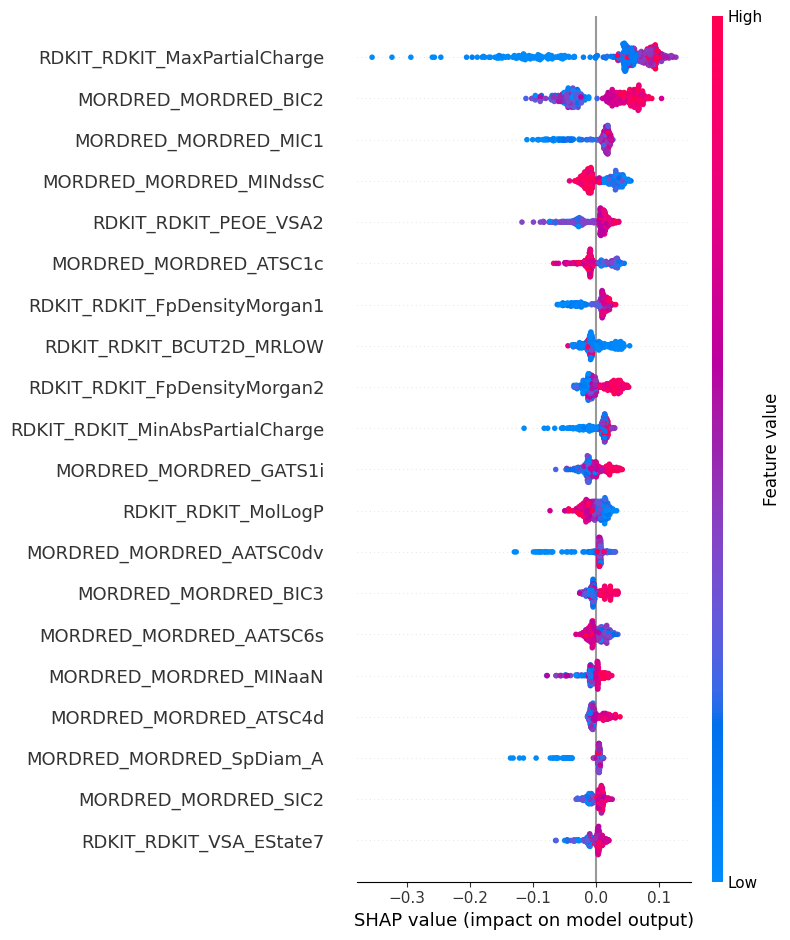


Top 20 SHAP features:
                              Feature  MeanAbsSHAP
10       RDKIT_RDKIT_MaxPartialCharge     0.080301
1246             MORDRED_MORDRED_BIC2     0.047797
1257             MORDRED_MORDRED_MIC1     0.022749
1170          MORDRED_MORDRED_MINdssC     0.020935
52              RDKIT_RDKIT_PEOE_VSA2     0.019034
427            MORDRED_MORDRED_ATSC1c     0.018219
14       RDKIT_RDKIT_FpDensityMorgan1     0.018032
24           RDKIT_RDKIT_BCUT2D_MRLOW     0.017157
15       RDKIT_RDKIT_FpDensityMorgan2     0.016149
13    RDKIT_RDKIT_MinAbsPartialCharge     0.015457
826            MORDRED_MORDRED_GATS1i     0.014422
127               RDKIT_RDKIT_MolLogP     0.013221
543          MORDRED_MORDRED_AATSC0dv     0.011513
1247             MORDRED_MORDRED_BIC3     0.010913
567           MORDRED_MORDRED_AATSC6s     0.010604
1173           MORDRED_MORDRED_MINaaN     0.009026
448            MORDRED_MORDRED_ATSC4d     0.008976
200          MORDRED_MORDRED_SpDiam_A     0.008973
1240    

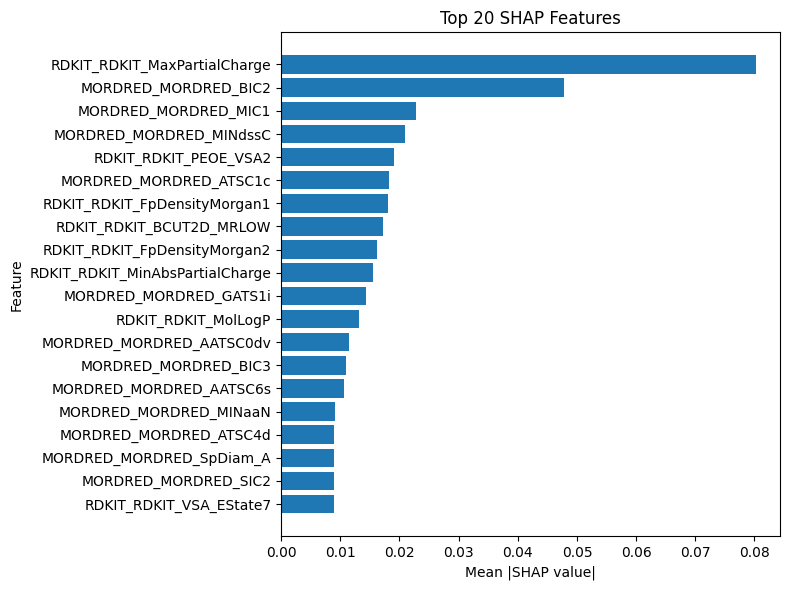


Number of selected top SHAP features: 50
Selected X_train shape: (1635, 50)
Selected X_test shape: (409, 50)

Performance after SHAP feature selection:
            Model      RMSE       MAE        R2
0   RF - Selected  0.345795  0.250307  0.667867
2  XGB - Selected  0.349596  0.255186  0.660524
1  GBM - Selected  0.361926  0.268190  0.636157


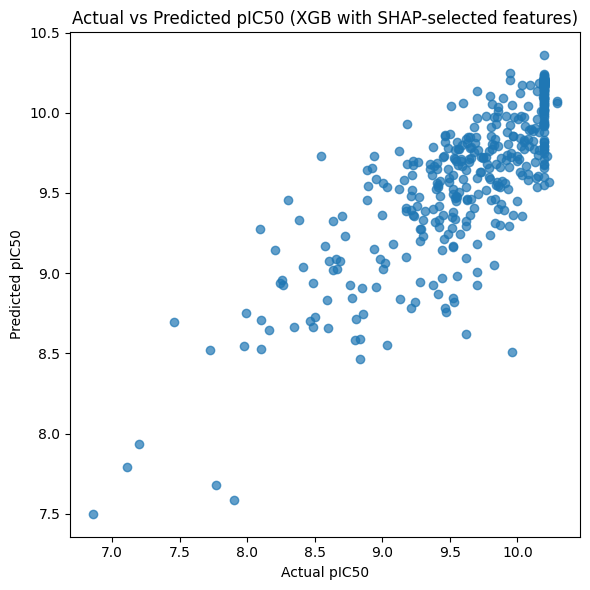

In [21]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# TreeExplainer works well for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# SHAP values on test set
shap_values = explainer.shap_values(X_test)

# 11. SHAP summary plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

# 12. SHAP feature importance table

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "MeanAbsSHAP": np.abs(shap_values).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

print("\nTop 20 SHAP features:")
print(shap_importance.head(20))

# 13. Bar plot of top 20 SHAP features

top20_shap = shap_importance.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top20_shap["Feature"][::-1], top20_shap["MeanAbsSHAP"][::-1])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("Top 20 SHAP Features")
plt.tight_layout()
plt.show()

# 14. Select top features from SHAP

top_features = shap_importance.head(50)["Feature"].tolist()
print("\nNumber of selected top SHAP features:", len(top_features))

X_train_sel = X_train[top_features]
X_test_sel = X_test[top_features]

print("Selected X_train shape:", X_train_sel.shape)
print("Selected X_test shape:", X_test_sel.shape)


# 15. Retrain models using selected SHAP features

selected_models = {
    "RF - Selected": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "GBM - Selected": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGB - Selected": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

selected_results = []

for name, model in selected_models.items():
    model.fit(X_train_sel, y_train)
    pred = model.predict(X_test_sel)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    selected_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

selected_results_df = pd.DataFrame(selected_results).sort_values("R2", ascending=False)

print("\nPerformance after SHAP feature selection:")
print(selected_results_df)

# 16. Optional: actual vs predicted plot for best selected model

best_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_sel, y_train)
best_pred = best_model.predict(X_test_sel)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.7)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50 (XGB with SHAP-selected features)")
plt.tight_layout()
plt.show()

X_test_sample = X_test.sample(min(200, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_test_sample)

In [22]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Machine": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

In [23]:
feature_sets = {
    "Descriptors": X_desc,
    "MACCS": X_maccs,
    "Morgan": X_morgan,
    "MACCS + Morgan": X_fp_combined,
    "All Features": X_all
}

all_results = []

for fs_name, X_curr in feature_sets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_curr, y, test_size=0.2, random_state=42
    )

    print(f"\n{fs_name}")
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        mae = mean_absolute_error(y_test, pred)
        r2 = r2_score(y_test, pred)

        all_results.append({
            "Feature_Set": fs_name,
            "Model": model_name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

results_df = pd.DataFrame(all_results).sort_values(["Feature_Set", "R2"], ascending=[True, False])
print(results_df)


Descriptors
X_train shape: (1635, 1491)
X_test shape: (409, 1491)

MACCS
X_train shape: (1635, 133)
X_test shape: (409, 133)

Morgan
X_train shape: (1635, 1005)
X_test shape: (409, 1005)

MACCS + Morgan
X_train shape: (1635, 1138)
X_test shape: (409, 1138)

All Features
X_train shape: (1635, 2629)
X_test shape: (409, 2629)
       Feature_Set                      Model      RMSE       MAE        R2
13    All Features  Gradient Boosting Machine  0.331301  0.243286  0.695126
14    All Features                    XGBoost  0.341314  0.247000  0.676419
12    All Features              Random Forest  0.345296  0.252245  0.668824
1      Descriptors  Gradient Boosting Machine  0.341790  0.248810  0.675515
0      Descriptors              Random Forest  0.345671  0.252173  0.668105
2      Descriptors                    XGBoost  0.347821  0.251402  0.663963
3            MACCS              Random Forest  0.384078  0.277841  0.590254
4            MACCS  Gradient Boosting Machine  0.384517  0.287490 

In [24]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [25]:
X = X_all.copy()
y = df["pIC50"].copy()

print("All Features shape:", X.shape)

All Features shape: (2044, 2629)


In [26]:
# 2. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1635, 2629)
X_test shape: (409, 2629)


In [27]:
# 3. Train GBM on all features
# -----------------------------
gbm_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm_model.fit(X_train, y_train)
pred_all = gbm_model.predict(X_test)

rmse_all = np.sqrt(mean_squared_error(y_test, pred_all))
mae_all = mean_absolute_error(y_test, pred_all)
r2_all = r2_score(y_test, pred_all)

print("\nPerformance on All Features:")
print(f"RMSE: {rmse_all:.6f}")
print(f"MAE:  {mae_all:.6f}")
print(f"R2:   {r2_all:.6f}")


Performance on All Features:
RMSE: 0.331301
MAE:  0.243286
R2:   0.695126


# Section 5 Error Analysis for GBM Model

In [36]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Redo the split so SMILES stay aligned with X and y
X_train_ea, X_test_ea, y_train_ea, y_test_ea, smiles_train_ea, smiles_test_ea = train_test_split(
    X, y, df["Smiles"],
    test_size=0.2,
    random_state=42
)

# Refit the same GBM model on the aligned split
gbm_model_ea = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbm_model_ea.fit(X_train_ea, y_train_ea)
pred_ea = gbm_model_ea.predict(X_test_ea)

# Build error dataframe
error_df = pd.DataFrame({
    "Smiles": smiles_test_ea.values,
    "Actual_pIC50": y_test_ea.values,
    "Predicted_pIC50": pred_ea
})

error_df["Residual"] = error_df["Actual_pIC50"] - error_df["Predicted_pIC50"]
error_df["Abs_Error"] = error_df["Residual"].abs()

# Sort worst predictions
error_df_sorted = error_df.sort_values("Abs_Error", ascending=False).reset_index(drop=True)

print("Top 20 worst predictions:")
print(error_df_sorted.head(20))

Top 20 worst predictions:
                                               Smiles  Actual_pIC50  \
0   Clc1c(/C=C/c2c(C)c(-c3c(C)c(/C=C/c4c(Cl)cc(CNC...      8.091515   
1   Clc1c(-c2c(Cl)c(-c3cc4c(C(N)CC4)cc3)ccc2)cccc1...      9.962573   
2   FC(F)(F)c1c(OCc2c(C)c(-c3c(C)c(COc4c(C(F)(F)F)...      7.460924   
3   Clc1c(-c2c(Cl)c(-c3nc(Cl)c(CN4CC5(NC(=O)CC5)C4...      8.385525   
4   Clc1c(-c2c(Cl)c(-c3nc(OC)c(CN4CC5(NC(=O)CC5)C4...      8.208449   
5   Clc1c(-c2c(Cl)c(-c3nc(OC)c(C4=NCC(F)(F)CN4)nc3...      9.939302   
6   Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNCC4NC(=O)OC4)nc3)...      8.922996   
7   Clc1c(OCc2c(C)c(-c3c4c(N(C(=O)c5cc(OCc6cc(C#N)...      8.161151   
8   Clc1c(-c2c(Cl)c(-c3ccc(OCCN4C(=O)C(C)(C)NC4=N)...      8.301987   
9   Clc1c(OCc2c(C)c(-c3c(C)c(COc4c(Cl)cc(CNCCO)c(O...      6.859178   
10  Clc1c(-c2c(Cl)c(-c3nc(OC)c([C@H](N)C)cc3)ccc2)...      8.547141   
11  Clc1c(COc2nc(OC)c(CNCCO)cc2)cccc1-c1c(Cl)c(COc...      7.725842   
12  Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNCCN4C(=O)C=CC=C4).

In [37]:
# Merge worst predictions back with original dataset
worst_20 = error_df_sorted.head(20).merge(
    df[["Smiles", "pIC50"]],
    on="Smiles",
    how="left"
)

print("\nWorst 20 molecules:")
print(worst_20)


Worst 20 molecules:
                                               Smiles  Actual_pIC50  \
0   Clc1c(/C=C/c2c(C)c(-c3c(C)c(/C=C/c4c(Cl)cc(CNC...      8.091515   
1   Clc1c(-c2c(Cl)c(-c3cc4c(C(N)CC4)cc3)ccc2)cccc1...      9.962573   
2   FC(F)(F)c1c(OCc2c(C)c(-c3c(C)c(COc4c(C(F)(F)F)...      7.460924   
3   Clc1c(-c2c(Cl)c(-c3nc(Cl)c(CN4CC5(NC(=O)CC5)C4...      8.385525   
4   Clc1c(-c2c(Cl)c(-c3nc(OC)c(CN4CC5(NC(=O)CC5)C4...      8.208449   
5   Clc1c(-c2c(Cl)c(-c3nc(OC)c(C4=NCC(F)(F)CN4)nc3...      9.939302   
6   Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNCC4NC(=O)OC4)nc3)...      8.922996   
7   Clc1c(OCc2c(C)c(-c3c4c(N(C(=O)c5cc(OCc6cc(C#N)...      8.161151   
8   Clc1c(-c2c(Cl)c(-c3ccc(OCCN4C(=O)C(C)(C)NC4=N)...      8.301987   
9   Clc1c(OCc2c(C)c(-c3c(C)c(COc4c(Cl)cc(CNCCO)c(O...      6.859178   
10  Clc1c(-c2c(Cl)c(-c3nc(OC)c([C@H](N)C)cc3)ccc2)...      8.547141   
11  Clc1c(COc2nc(OC)c(CNCCO)cc2)cccc1-c1c(Cl)c(COc...      7.725842   
12  Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNCCN4C(=O)C=CC=C4)...   

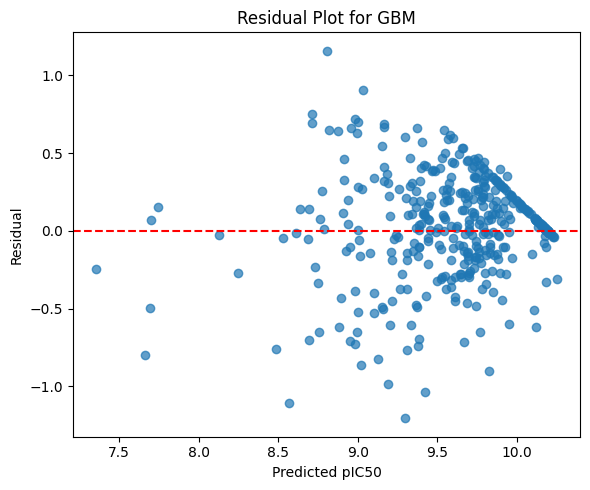

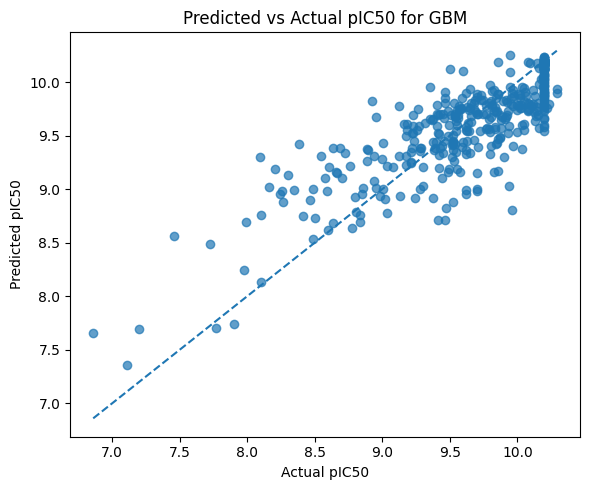

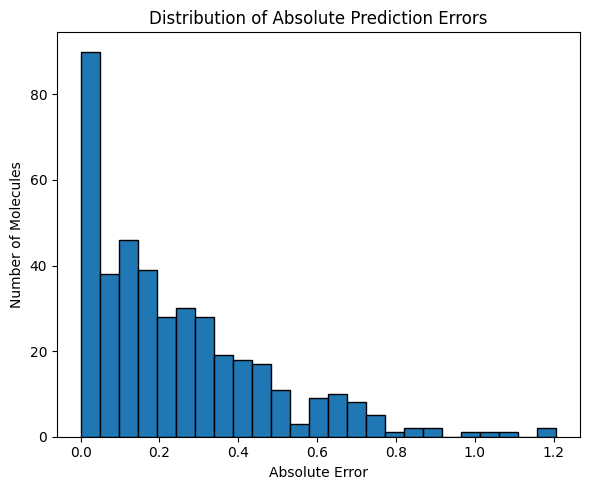

In [39]:
# Residual plot
plt.figure(figsize=(6,5))
plt.scatter(error_df["Predicted_pIC50"], error_df["Residual"], alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted pIC50")
plt.ylabel("Residual")
plt.title("Residual Plot for GBM")
plt.tight_layout()
plt.show()

# Predicted vs Actual
plt.figure(figsize=(6,5))
plt.scatter(error_df["Actual_pIC50"], error_df["Predicted_pIC50"], alpha=0.7)

min_val = min(error_df["Actual_pIC50"].min(), error_df["Predicted_pIC50"].min())
max_val = max(error_df["Actual_pIC50"].max(), error_df["Predicted_pIC50"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predicted vs Actual pIC50 for GBM")
plt.tight_layout()
plt.show()

# Distribution of absolute errors
plt.figure(figsize=(6,5))
plt.hist(error_df["Abs_Error"], bins=25, edgecolor="black")
plt.xlabel("Absolute Error")
plt.ylabel("Number of Molecules")
plt.title("Distribution of Absolute Prediction Errors")
plt.tight_layout()
plt.show()

#Section 6 GBM feature importance

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance from GBM
gbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gbm_model.feature_importances_
})

# Sort descending
gbm_importance = gbm_importance.sort_values("Importance", ascending=False).reset_index(drop=True)

# Top 20 most important features
top20_gbm = gbm_importance.head(20)

print(top20_gbm)

                            Feature  Importance
0      RDKIT_RDKIT_MaxPartialCharge    0.081750
1   RDKIT_RDKIT_MinAbsPartialCharge    0.073551
2              MORDRED_MORDRED_BIC2    0.051085
3          MORDRED_MORDRED_SpDiam_A    0.043466
4              MORDRED_MORDRED_MIC1    0.032447
5            MORDRED_MORDRED_AXp-6d    0.028037
6              MORDRED_MORDRED_BIC3    0.027331
7          MORDRED_MORDRED_SMR_VSA7    0.020658
8            MORDRED_MORDRED_ATSC1c    0.019845
9             MORDRED_MORDRED_NdssC    0.016952
10        MORDRED_MORDRED_PEOE_VSA2    0.016149
11         MORDRED_MORDRED_AATSC0dv    0.014501
12         RDKIT_RDKIT_BCUT2D_MRLOW    0.013986
13     RDKIT_RDKIT_FpDensityMorgan2    0.011227
14            RDKIT_RDKIT_PEOE_VSA2    0.010944
15            MORDRED_MORDRED_piPC6    0.010386
16     MORDRED_MORDRED_FilterItLogS    0.010003
17                       Morgan_893    0.009473
18    MORDRED_MORDRED_ETA_epsilon_5    0.008831
19             MORDRED_MORDRED_JGI3    0

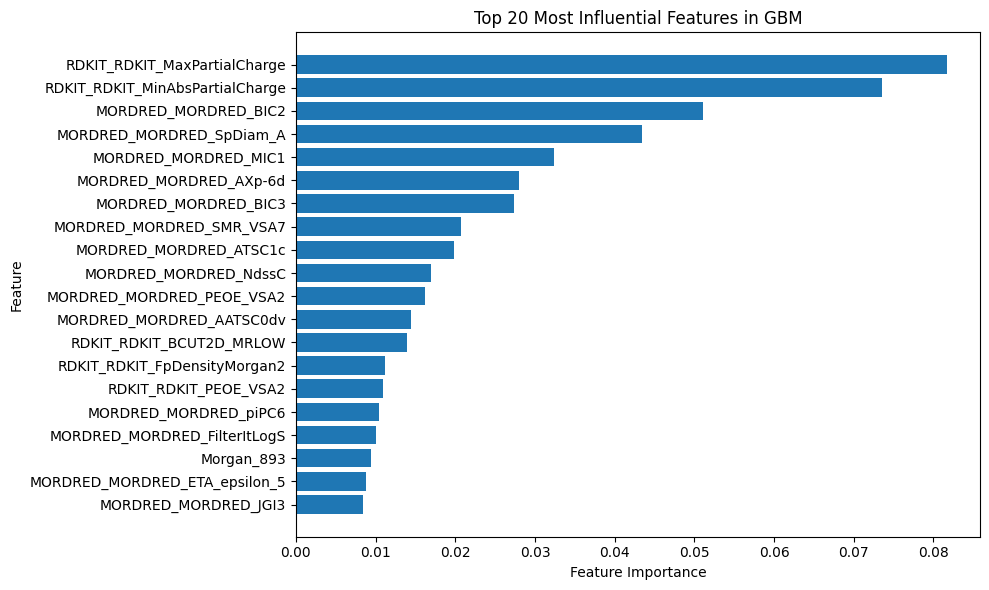

In [43]:
plt.figure(figsize=(10,6))
plt.barh(top20_gbm["Feature"][::-1], top20_gbm["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Influential Features in GBM")
plt.tight_layout()
plt.show()

In [40]:
# Define high-error molecules as top 20% of absolute errors
threshold = error_df["Abs_Error"].quantile(0.80)

high_error_smiles = error_df[error_df["Abs_Error"] >= threshold]["Smiles"]
low_error_smiles = error_df[error_df["Abs_Error"] < threshold]["Smiles"]

# Add SMILES back to feature matrix
X_with_smiles = X.copy()
X_with_smiles["Smiles"] = df["Smiles"].values

high_error_features = X_with_smiles[X_with_smiles["Smiles"].isin(high_error_smiles)].drop(columns=["Smiles"])
low_error_features = X_with_smiles[X_with_smiles["Smiles"].isin(low_error_smiles)].drop(columns=["Smiles"])

comparison = pd.DataFrame({
    "High_Error_Mean": high_error_features.mean(numeric_only=True),
    "Low_Error_Mean": low_error_features.mean(numeric_only=True)
})

comparison["Difference"] = comparison["High_Error_Mean"] - comparison["Low_Error_Mean"]
comparison["Abs_Difference"] = comparison["Difference"].abs()

comparison_sorted = comparison.sort_values("Abs_Difference", ascending=False)

print("\nTop 20 feature differences between high-error and low-error molecules:")
print(comparison_sorted.head(20))


Top 20 feature differences between high-error and low-error molecules:
                        High_Error_Mean  Low_Error_Mean    Difference  \
RDKIT_RDKIT_Ipc            3.790800e+13    1.283620e+14 -9.045404e+13   
MORDRED_MORDRED_VR1_A      3.365828e+03    3.940319e+04 -3.603736e+04   
MORDRED_MORDRED_VR2_A      6.253613e+01    7.385129e+02 -6.759768e+02   
MORDRED_MORDRED_ATS6i      3.814109e+04    3.862991e+04 -4.888164e+02   
MORDRED_MORDRED_ATS3i      3.355705e+04    3.403266e+04 -4.756176e+02   
MORDRED_MORDRED_ATSC8v     1.219132e+01   -4.472298e+02  4.594211e+02   
MORDRED_MORDRED_ATSC8m    -7.592122e+02   -1.216530e+03  4.573173e+02   
MORDRED_MORDRED_ATS6m      1.696357e+04    1.740544e+04 -4.418638e+02   
MORDRED_MORDRED_ATS4i      3.869615e+04    3.910858e+04 -4.124314e+02   
MORDRED_MORDRED_WPath      1.309675e+04    1.269792e+04  3.988251e+02   
MORDRED_MORDRED_ATS6v      4.571218e+04    4.610478e+04 -3.925999e+02   
MORDRED_MORDRED_ATS0m      1.125292e+04    1.095004e

In [41]:
# Look specifically at highly potent molecules
high_potency_errors = error_df[error_df["Actual_pIC50"] >= 9].sort_values("Abs_Error", ascending=False)

print("\nHighly potent molecules with largest errors:")
print(high_potency_errors.head(10))


Highly potent molecules with largest errors:
                                                Smiles  Actual_pIC50  \
302  Clc1c(-c2c(Cl)c(-c3cc4c(C(N)CC4)cc3)ccc2)cccc1...      9.962573   
282  Clc1c(-c2c(Cl)c(-c3nc(OC)c(C4=NCC(F)(F)CN4)nc3...      9.939302   
385  Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNCCN4C(=O)C=CC=C4)...      9.465974   
203  Clc1c(OCc2c(C)c(-c3c(C)c(COc4c(Cl)cc(CNC[C@@H]...      9.698970   
88   O=C(O)C[C@H](O)CNCc1c(OCc2cncnc2)nc(OCc2c(C)c(...      9.698970   
147  Clc1c(-c2c(Cl)c(-c3nc(OC)c(CNC[C@H]4NC(=O)CC4)...      9.412289   
73   Clc1c(NC(=O)c2nc(OC)c(CNC[C@H]3NC(=O)CC3)cc2)c...      9.853872   
329  Clc1c(OCc2c(C)c(-c3c(C)c(COc4c(Cl)cc(CNCC(=O)N...      9.829739   
98   Clc1c(-c2c(Cl)c(-c3nc(OC)c(CN4CCCC4)cc3)ccc2)c...      9.617983   
387  Clc1c(-c2c(Cl)c(-c3nc(OC)c(CN4CC5(CN(C=O)C5)C4...     10.031517   

     Predicted_pIC50  Residual  Abs_Error  
302         8.804091  1.158482   1.158482  
282         9.032184  0.907118   0.907118  
385         8.711471  0.75450

In [28]:
# make sure SHAP sees only numeric float data
X_train_shap = X_train.apply(pd.to_numeric, errors="coerce").astype(float)
X_test_shap = X_test.apply(pd.to_numeric, errors="coerce").astype(float)

# fill any remaining missing values
X_train_shap = X_train_shap.fillna(X_train_shap.median())
X_test_shap = X_test_shap.fillna(X_train_shap.median())

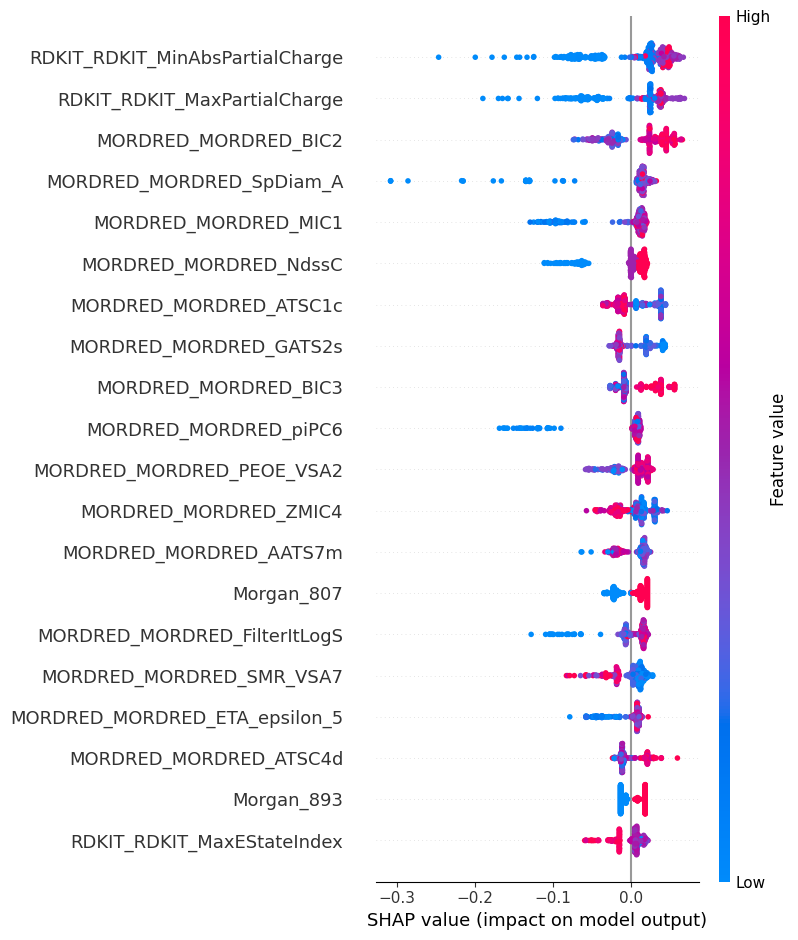

In [29]:
explainer = shap.Explainer(gbm_model, X_train_shap)
shap_values = explainer(X_test_shap)

shap.summary_plot(shap_values, X_test_shap)

float64    2629
Name: count, dtype: int64
Any object dtype left? False


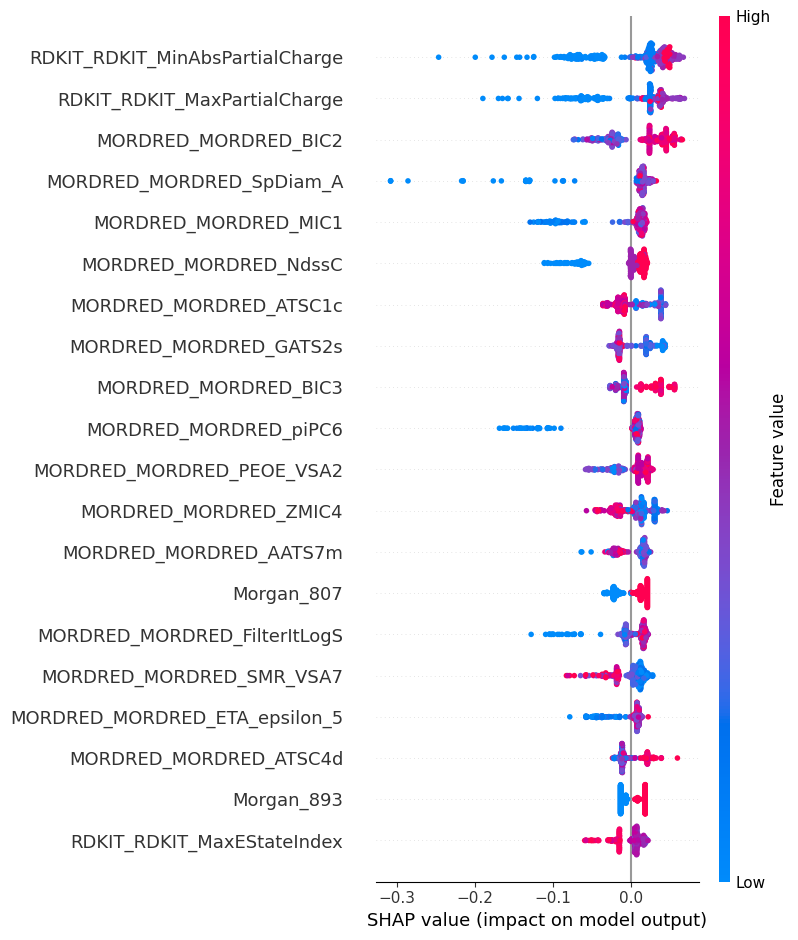


Top 20 SHAP features:
                              Feature  MeanAbsSHAP
13    RDKIT_RDKIT_MinAbsPartialCharge     0.043824
10       RDKIT_RDKIT_MaxPartialCharge     0.040950
1246             MORDRED_MORDRED_BIC2     0.033992
200          MORDRED_MORDRED_SpDiam_A     0.026247
1257             MORDRED_MORDRED_MIC1     0.025664
1091            MORDRED_MORDRED_NdssC     0.021105
427            MORDRED_MORDRED_ATSC1c     0.019794
763            MORDRED_MORDRED_GATS2s     0.019581
1247             MORDRED_MORDRED_BIC3     0.019560
1362            MORDRED_MORDRED_piPC6     0.018540
1276        MORDRED_MORDRED_PEOE_VSA2     0.018054
1266            MORDRED_MORDRED_ZMIC4     0.017769
370            MORDRED_MORDRED_AATS7m     0.017594
2416                       Morgan_807     0.017105
1272     MORDRED_MORDRED_FilterItLogS     0.016416
1294         MORDRED_MORDRED_SMR_VSA7     0.014724
1213    MORDRED_MORDRED_ETA_epsilon_5     0.014370
448            MORDRED_MORDRED_ATSC4d     0.014247
2498    

In [30]:
# -----------------------------
# 4. SHAP analysis
# -----------------------------
X_train_shap = X_train.apply(pd.to_numeric, errors="coerce").astype(float)
X_test_shap = X_test.apply(pd.to_numeric, errors="coerce").astype(float)

X_train_shap = X_train_shap.fillna(X_train_shap.median())
X_test_shap = X_test_shap.fillna(X_train_shap.median())

print(X_train_shap.dtypes.value_counts())
print("Any object dtype left?", (X_train_shap.dtypes == "object").any())

explainer = shap.Explainer(gbm_model, X_train_shap)
shap_values = explainer(X_test_shap)

shap.summary_plot(shap_values, X_test_shap)

# SHAP importance table
shap_importance = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "MeanAbsSHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

print("\nTop 20 SHAP features:")
print(shap_importance.head(20))

In [31]:
X_all = X_all.apply(pd.to_numeric, errors="coerce").astype(float)
X_all = X_all.replace([np.inf, -np.inf], np.nan)
X_all = X_all.fillna(X_all.median())

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

In [33]:
#Select top SHAP features
top_n = 100   # try 50, 100, 150, 200
top_features = shap_importance.head(top_n)["Feature"].tolist()

print(f"\nNumber of selected top SHAP features: {len(top_features)}")

X_train_sel = X_train_shap[top_features].copy()
X_test_sel = X_test_shap[top_features].copy()

print("Selected X_train shape:", X_train_sel.shape)
print("Selected X_test shape:", X_test_sel.shape)


Number of selected top SHAP features: 100
Selected X_train shape: (1635, 100)
Selected X_test shape: (409, 100)


In [34]:
#retrain models on top SHAP features
selected_models = {
    "RF - Selected": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "GBM - Selected": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGB - Selected": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

selected_results = []

for name, model in selected_models.items():
    model.fit(X_train_sel, y_train)
    pred = model.predict(X_test_sel)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    selected_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

selected_results_df = pd.DataFrame(selected_results).sort_values("R2", ascending=False)

print("\nPerformance after SHAP feature selection:")
print(selected_results_df)


Performance after SHAP feature selection:
            Model      RMSE       MAE        R2
0   RF - Selected  0.335300  0.241558  0.687722
2  XGB - Selected  0.341642  0.243271  0.675797
1  GBM - Selected  0.342803  0.249413  0.673589


In [35]:
#Compare before vs after
comparison_df = pd.DataFrame([
    {
        "Stage": "All Features (GBM baseline)",
        "RMSE": rmse_all,
        "MAE": mae_all,
        "R2": r2_all
    },
    {
        "Stage": "Best SHAP-Selected Model",
        "RMSE": selected_results_df.iloc[0]["RMSE"],
        "MAE": selected_results_df.iloc[0]["MAE"],
        "R2": selected_results_df.iloc[0]["R2"]
    }
])

print("\nComparison:")
print(comparison_df)


Comparison:
                         Stage      RMSE       MAE        R2
0  All Features (GBM baseline)  0.331301  0.243286  0.695126
1     Best SHAP-Selected Model  0.335300  0.241558  0.687722
